In [46]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib

In [47]:
# Load the clustered dataset directly
df = pd.read_csv('../weather-data-csv/baringo_clustered_data.csv')

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4018 non-null   int64  
 1   temperature    4018 non-null   float64
 2   dew_point      4018 non-null   float64
 3   humidity       4018 non-null   float64
 4   wind_speed     4018 non-null   float64
 5   pressure       4018 non-null   float64
 6   precipitation  4018 non-null   float64
 7   region_id      4018 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 282.5 KB


In [48]:
df['7_day_cum_precip'] = df['precipitation'].rolling(window=7).sum()

# Normalize features (min-max scaling)
df['norm_precip'] = 1 - (df['7_day_cum_precip'] / df['7_day_cum_precip'].max())  # Inverse: lower precipitation → higher drought risk
df['norm_temp'] = df['temperature'] / df['temperature'].max()
df['norm_humidity'] = 1 - (df['humidity'] / df['humidity'].max())  # Inverse: lower humidity → higher drought risk
df['norm_pressure'] = df['pressure'] / df['pressure'].max()  # Higher pressure → more drought risk

# Weighted sum of features (tuned weights based on analysis)
df['drought_probability'] = (
    (df['norm_precip'] * 0.5) +  
    (df['norm_temp'] * 0.3) +  
    (df['norm_humidity'] * 0.15) +  
    (df['norm_pressure'] * 0.05)  
)

# Clip values to ensure probability range (0 to 1)
df['drought_probability'] = df['drought_probability'].clip(0, 1)

In [49]:
# Select features for LSTM
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'drought_probability' 

df.head()

,Unnamed: 0,temperature,dew_point,humidity,wind_speed,pressure,precipitation,region_id,7_day_cum_precip,norm_precip,norm_temp,norm_humidity,norm_pressure,drought_probability
time,,,,,,,,,,,,,,
2010-01-01,0,18.0,14.0,85.0,5.0,29.91,23.0,3,NaN,NaN,0.750000,0.132653,0.994018,NaN
2010-01-02,1,18.0,16.0,89.0,6.0,29.94,28.8,3,NaN,NaN,0.750000,0.091837,0.995015,NaN
2010-01-03,2,18.0,14.0,82.0,10.0,29.94,2.5,0,NaN,NaN,0.750000,0.163265,0.995015,NaN
2010-01-04,3,18.0,13.0,76.0,9.0,29.94,1.7,2,NaN,NaN,0.750000,0.224490,0.995015,NaN
2010-01-05,4,19.0,12.0,69.0,10.0,29.91,1.3,2,NaN,NaN,0.791667,0.295918,0.994018,NaN


In [50]:
# 🔹 Normalize input features (min-max scaling)
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [51]:
# 🔹 Prepare sequences for LSTM
sequence_length = 20  # Using last 20 days as input for prediction
X, y = [], []

for i in range(sequence_length, len(df)):
    X.append(df[features].iloc[i-sequence_length:i].values)
    y.append(df[target].iloc[i])

X, y = np.array(X), np.array(y)

# 🔹 Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


In [52]:
# 🔹 Build LSTM Model
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(sequence_length, len(features))),
    Dropout(0.4),
    LSTM(100, return_sequences=False),
    Dropout(0.4),
    
    # Dense models to modify the output
    Dense(30, activation='relu'),
    Dense(1, activation='sigmoid')  # Output is between 0 and 1
])

# Compile Model (define the model)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(), metrics=['mae'])

# Train Model
train_hist = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/100


/home/ronny/rada-project/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0074 - mae: 0.0859 - val_loss: 0.0011 - val_mae: 0.0333
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 9.9393e-04 - mae: 0.0345 - val_loss: 6.4360e-04 - val_mae: 0.0251
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.2079e-04 - mae: 0.0288 - val_loss: 5.6752e-04 - val_mae: 0.0239
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 6.7299e-04 - mae: 0.0275 - val_loss: 4.6824e-04 - val_mae: 0.0214
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 5.8291e-04 - mae: 0.0260 - val_loss: 4.3010e-04 - val_mae: 0.0213
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 5.9766e-04 - mae: 0.0258 - val_loss: 4.5531e-04 - val_mae: 0.0227
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.6980e-04 - mae: 0.0254 - val_loss: 4.9837e-04 - val_mae: 0.0248
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 5.1237e-04 - mae: 0.0240 - val_loss: 4.9680e-04 - val_mae: 0.0

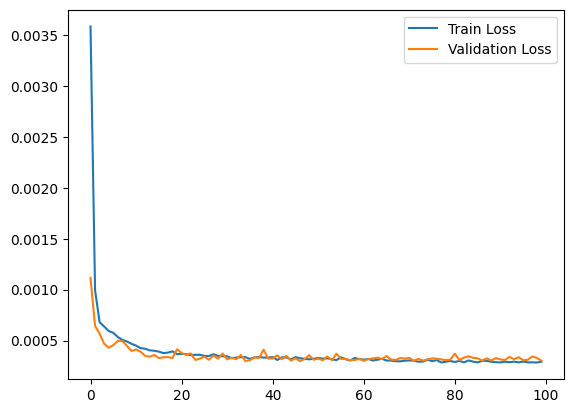

In [53]:
# Plot training loss
plt.plot(train_hist.history['loss'], label='Train Loss')
plt.plot(train_hist.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [55]:
# 🔹 Model Evaluation
y_pred = model.predict(X_test)

# Convert predictions back to original scale
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
RMSE: 0.024588843520218562
MAE: 0.017137475458020895
MSE: 0.0006046112256617943


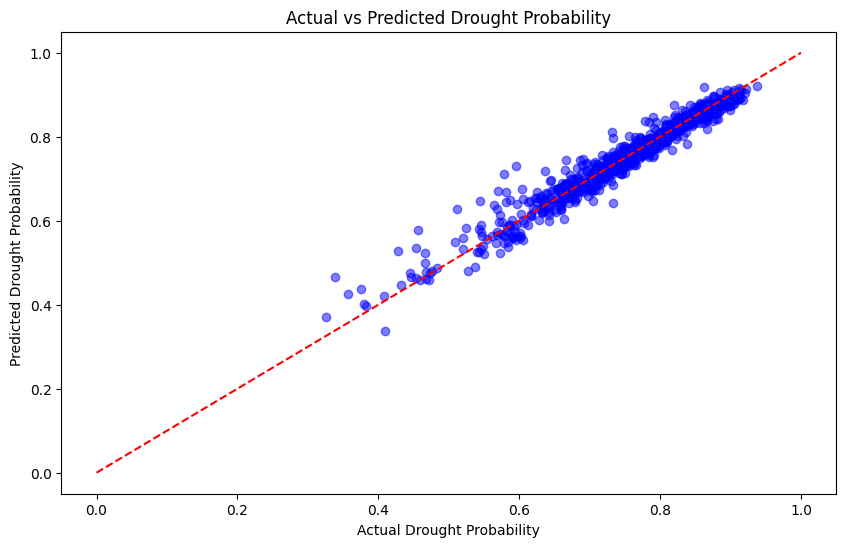

In [56]:
# 🔹 Plot Actual vs Predicted for ALL DATA
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Perfect prediction line
plt.xlabel("Actual Drought Probability")
plt.ylabel("Predicted Drought Probability")
plt.title("Actual vs Predicted Drought Probability")
plt.show()

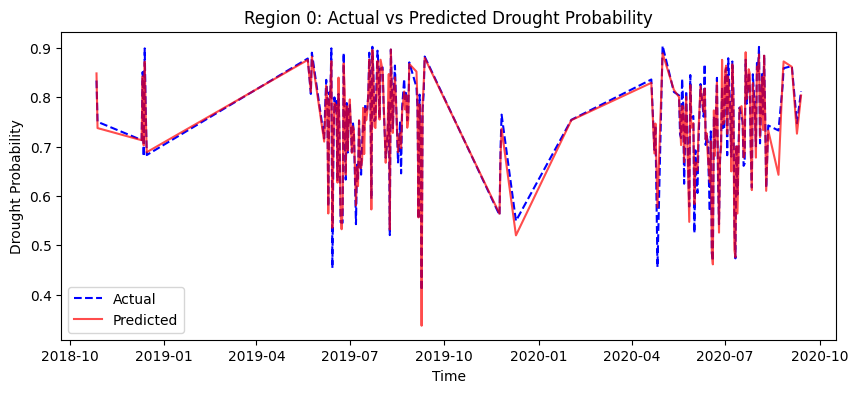

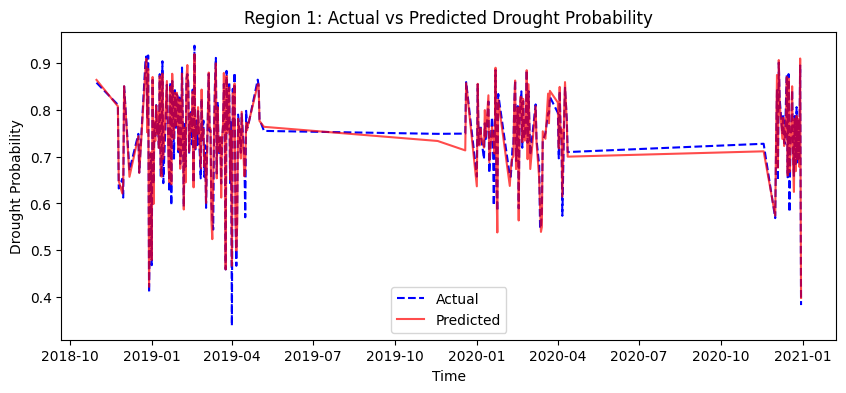

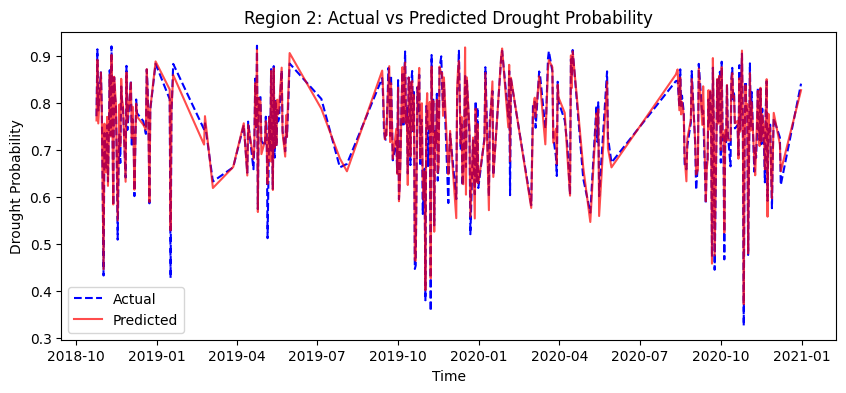

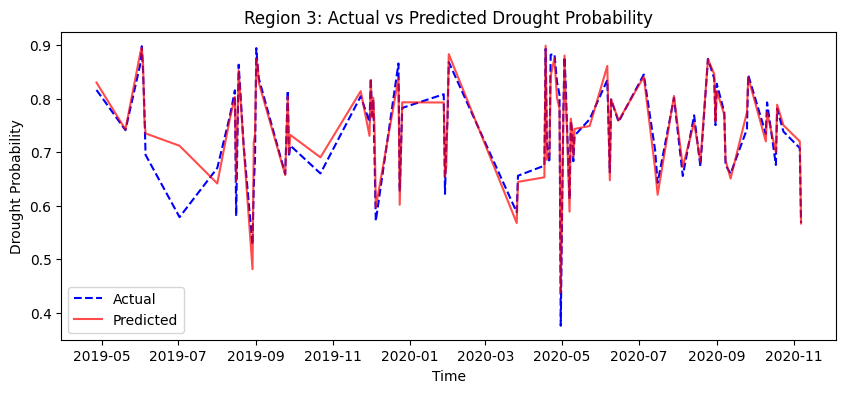

In [57]:
regions_test = df['region_id'].iloc[-len(y_test):].values  # Extract region IDs

regions_unique = np.unique(regions_test)  # Get unique regions

for region in regions_unique:
    plt.figure(figsize=(10, 4))
    
    mask = (regions_test == region)  # Filter data for each region
    
    plt.plot(df.index[-len(y_test):][mask], y_test[mask], linestyle='dashed', color='blue', label="Actual")
    plt.plot(df.index[-len(y_test):][mask], y_pred[mask], color='red', alpha=0.7, label="Predicted")
    
    plt.legend()
    plt.title(f"Region {region}: Actual vs Predicted Drought Probability")
    plt.xlabel("Time")
    plt.ylabel("Drought Probability")
    
    plt.show()


In [58]:
# Ensure y_test and y_pred are 1D arrays
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred).flatten()
regions_flat = np.array(regions_test).flatten()

# Convert predictions and actual values into a DataFrame for easy comparison
results_df = pd.DataFrame({
    "Date": df.index[-len(y_test_flat):],  # Match the test set length
    "Region": regions_flat,
    "Actual Drought Probability": y_test_flat,
    "Predicted Drought Probability": y_pred_flat
})

# Display a random sample of 10 rows
sample_results = results_df.sample(10, random_state=42)  # Set seed for reproducibility
print(sample_results)

          Date  Region  Actual Drought Probability  \
696 2020-09-19       2                    0.828505   
667 2020-08-21       2                    0.670062   
63  2018-12-26       1                    0.914904   
533 2020-04-09       1                    0.847654   
66  2018-12-29       1                    0.408345   
621 2020-07-06       0                    0.766165   
346 2019-10-05       2                    0.801684   
490 2020-02-26       1                    0.885583   
760 2020-11-22       2                    0.846712   
456 2020-01-23       1                    0.637746   

     Predicted Drought Probability  
696                       0.826835  
667                       0.684467  
63                        0.909860  
533                       0.859893  
66                        0.421247  
621                       0.761451  
346                       0.805607  
490                       0.885384  
760                       0.851164  
456                       0.647210 

In [59]:
# Filter cases where predicted flood probability is above 80%
high_risk_floods = results_df[results_df["Predicted Drought Probability"] > 0.55]

# Display the high-risk cases
print(high_risk_floods)

          Date  Region  Actual Drought Probability  \
0   2018-10-24       2                    0.772109   
1   2018-10-25       2                    0.914865   
2   2018-10-26       2                    0.784392   
3   2018-10-27       0                    0.834086   
4   2018-10-28       0                    0.750378   
..         ...     ...                         ...   
794 2020-12-26       1                    0.685540   
795 2020-12-27       1                    0.780366   
796 2020-12-28       1                    0.696746   
797 2020-12-29       1                    0.895513   
799 2020-12-31       2                    0.841569   

     Predicted Drought Probability  
0                         0.763103  
1                         0.892536  
2                         0.756726  
3                         0.848566  
4                         0.737657  
..                             ...  
794                       0.695001  
795                       0.780370  
796               